In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install tensorflow
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [ ]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.7976 - loss: 0.5615 - val_accuracy: 0.8541 - val_loss: 0.3989
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8658 - loss: 0.3732 - val_accuracy: 0.8824 - val_loss: 0.3243
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8838 - loss: 0.3241 - val_accuracy: 0.8982 - val_loss: 0.2834
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8947 - loss: 0.2912 - val_accuracy: 0.8985 - val_loss: 0.2739
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9015 - loss: 0.2691 - val_accuracy: 0.9022 - val_loss: 0.2697
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9084 - loss: 0.2492 - val_accuracy: 0.9091 - val_loss: 0.2531
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9138 - loss: 0.2356 - val_accuracy: 0.9022 - val_loss: 0.2837
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9176 - loss: 0.2228 -

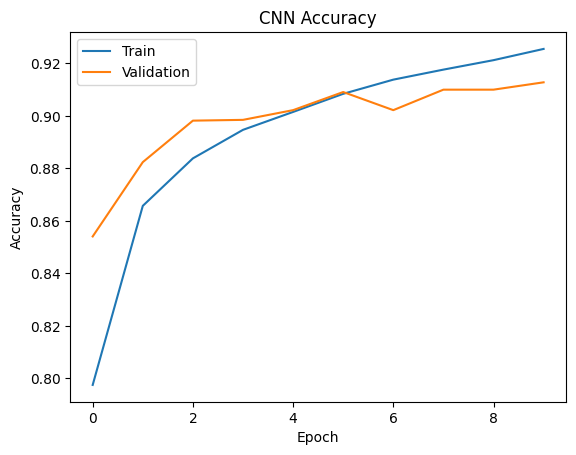

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.savefig('/content/drive/MyDrive/DL Assignment 2/GRAPHS/cnn_accuracy.png')
plt.show()

In [2]:
# Plot Loss Curve
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.savefig('cnn_loss.png')
plt.show()

NameError: name 'history' is not defined

<Figure size 640x480 with 0 Axes>

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


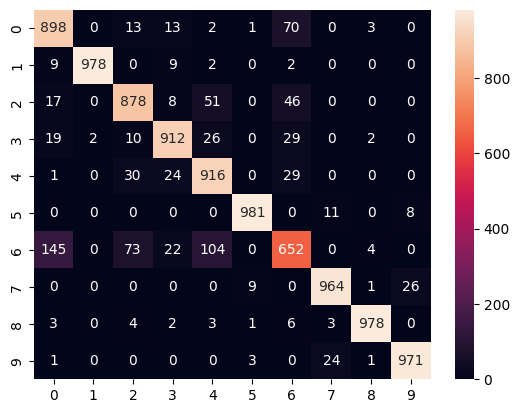

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.savefig('/content/drive/MyDrive/DL Assignment 2/CONFUSION MATRIX/cnn_cm.png')
plt.show()

# Transfer Learning CNN

In [ ]:
import tensorflow as tf

x_train_resized = tf.image.resize(x_train, (96,96))
x_test_resized = tf.image.resize(x_test, (96,96))

x_train_resized = tf.image.grayscale_to_rgb(x_train_resized)
x_test_resized = tf.image.grayscale_to_rgb(x_test_resized)

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model_tl = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_tl = model_tl.fit(
    x_train_resized, y_train,
    epochs=5,
    validation_data=(x_test_resized, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 18ms/step - accuracy: 0.8688 - loss: 0.3610 - val_accuracy: 0.8812 - val_loss: 0.3220
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8975 - loss: 0.2751 - val_accuracy: 0.8887 - val_loss: 0.3033
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9102 - loss: 0.2419 - val_accuracy: 0.8939 - val_loss: 0.2944
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9167 - loss: 0.2197 - val_accuracy: 0.8936 - val_loss: 0.2894
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9248 - loss: 0.1991 - val_accuracy: 0.8937 - val_loss: 0.2890


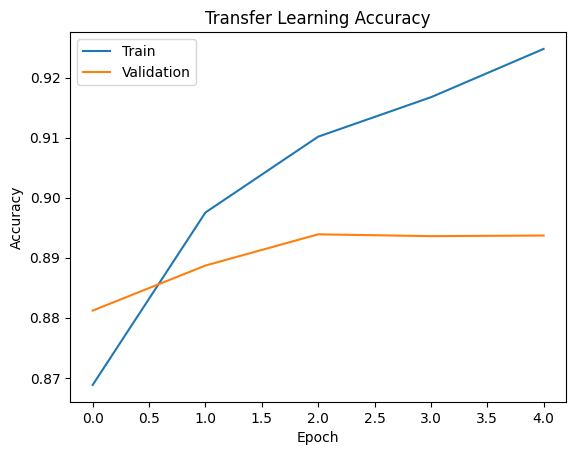

In [ ]:
plt.plot(history_tl.history['accuracy'])
plt.plot(history_tl.history['val_accuracy'])
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.savefig('/content/drive/MyDrive/DL Assignment 2/GRAPHS/transfer_learning_accuracy.png')
plt.show()

# RNN LSTM GRU - IMDB Text Classification

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000
max_len = 200

(x_train_text, y_train_text), (x_test_text, y_test_text) = imdb.load_data(num_words=vocab_size)

x_train_text = pad_sequences(x_train_text, maxlen=max_len)
x_test_text = pad_sequences(x_test_text, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
model_rnn = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_rnn = model_rnn.fit(
    x_train_text, y_train_text,
    epochs=5,
    validation_data=(x_test_text, y_test_text)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.7071 - loss: 0.5455 - val_accuracy: 0.8141 - val_loss: 0.4224
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.7290 - loss: 0.5224 - val_accuracy: 0.6594 - val_loss: 0.6011
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7728 - loss: 0.4850 - val_accuracy: 0.7822 - val_loss: 0.4810
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8444 - loss: 0.3699 - val_accuracy: 0.8296 - val_loss: 0.4142
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.8260 - loss: 0.3953 - val_accuracy: 0.6886 - val_loss: 0.5855


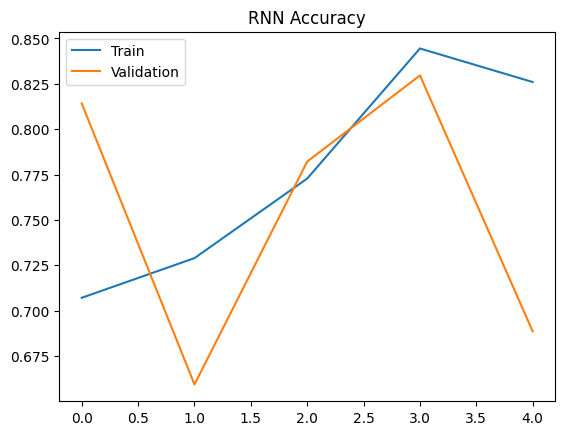

In [ ]:
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])
plt.title('RNN Accuracy')
plt.legend(['Train','Validation'])
plt.savefig('/content/drive/MyDrive/DL Assignment 2/GRAPHS/rnn_accuracy.png')
plt.show()

In [ ]:
model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    x_train_text, y_train_text,
    epochs=5,
    validation_data=(x_test_text, y_test_text)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.8121 - loss: 0.4121 - val_accuracy: 0.8178 - val_loss: 0.4206
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9023 - loss: 0.2494 - val_accuracy: 0.8676 - val_loss: 0.3154
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9304 - loss: 0.1835 - val_accuracy: 0.8518 - val_loss: 0.3832
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9409 - loss: 0.1540 - val_accuracy: 0.8551 - val_loss: 0.3653
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9618 - loss: 0.1083 - val_accuracy: 0.8621 - val_loss: 0.4308


In [ ]:
# Accuracy
plt.figure()
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.savefig('/content/drive/MyDrive/DL Assignment 2/GRAPHS/lstm_accuracy.png')
plt.close()

# Loss
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.savefig('/content/drive/MyDrive/DL Assignment 2/GRAPHS/lstm_loss.png')
plt.close()

In [ ]:
model_gru = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, 64),
    tf.keras.layers.GRU(64),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_gru = model_gru.fit(
    x_train_text, y_train_text,
    epochs=5,
    validation_data=(x_test_text, y_test_text)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8018 - loss: 0.4211 - val_accuracy: 0.8294 - val_loss: 0.4063
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9046 - loss: 0.2443 - val_accuracy: 0.8729 - val_loss: 0.3031
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9380 - loss: 0.1694 - val_accuracy: 0.8781 - val_loss: 0.3096
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9630 - loss: 0.1077 - val_accuracy: 0.8701 - val_loss: 0.3963
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.9761 - loss: 0.0700 - val_accuracy: 0.8594 - val_loss: 0.4393


In [ ]:
# Accuracy
plt.figure()
plt.plot(history_gru.history['accuracy'])
plt.plot(history_gru.history['val_accuracy'])
plt.title('GRU Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])
plt.savefig('/content/drive/MyDrive/DL Assignment 2/GRAPHS/gru_accuracy.png')
plt.close()

# Loss
plt.figure()
plt.plot(history_gru.history['loss'])
plt.plot(history_gru.history['val_loss'])
plt.title('GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train','Validation'])
plt.savefig('/content/drive/MyDrive/DL Assignment 2/GRAPHS/gru_loss.png')
plt.close()

# GAN - Fashion MNIST Image Generator

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
(train_images, _), _ = tf.keras.datasets.fashion_mnist.load_data()

train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5

BUFFER_SIZE = 60000
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices(train_images)\
                                .shuffle(BUFFER_SIZE)\
                                .batch(BATCH_SIZE)

In [ ]:
def make_generator():
    model = tf.keras.Sequential()

    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, (5,5), strides=(1,1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5,5), strides=(2,2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5,5), strides=(2,2), padding='same', use_bias=False, activation='tanh'))

    return model

generator = make_generator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
def make_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, (5,5), strides=(2,2), padding='same', input_shape=[28,28,1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5,5), strides=(2,2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

discriminator = make_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [ ]:
EPOCHS = 50
seed = tf.random.normal([16, 100])

g_losses = []
d_losses = []

def generate_and_save_images(epoch):
    predictions = generator(seed, training=False)

    for i in range(predictions.shape[0]):
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')
        plt.savefig(f'/content/drive/MyDrive/DL Assignment 2/Generated_Images/epoch_{epoch}_{i}.png')
        plt.close()

for epoch in range(EPOCHS):
    for image_batch in train_dataset:
        g_loss, d_loss = train_step(image_batch)

    g_losses.append(g_loss)
    d_losses.append(d_loss)

    if epoch % 5 == 0:
        print("Epoch:", epoch)
        generate_and_save_images(epoch)

Epoch: 0
Epoch: 5
Epoch: 10
Epoch: 15
Epoch: 20
Epoch: 25
Epoch: 30
Epoch: 35
Epoch: 40
Epoch: 45
